---
title: "DRG Cleaning v2"

author: "Carlos Resurreccion"

date: "2024-10-21"
---


# Libraries


In [1]:
# Update the grouper
system("git submodule update --init --recursive")

# Delete all R objects and run garbage collection so we start with a clean slate
rm(list = ls())
gc()

# List, install (if applicable), and load packages
## Required packages
required_packages <- c(
  "data.table", "here", "tictoc", "stringr", "stringi", "lubridate",
  "profvis", "hash", "future", "future.apply", "knitr", "htmlwidgets",
  "parallelly", "stringdist", "parallel", "reticulate", "bigrquery",
  "jsonlite", "googleCloudStorageR", "haven", "fst", "httr", "ggplot2",
  "rmarkdown"
  # , "docstring", "progress" # Comma is here so if I uncomment this line it
  # automatically works without having to type or delete a comma after haven
)

# Additional packages to install via remotes (GitHub), if not available
github_packages <- c("r-lib/styler")

# Function to install and load packages quietly
install_and_load <- function(package) {
  if (!require(package, character.only = TRUE)) {
    message("Installing ", package)
    install.packages(package, dependencies = TRUE)
  } else {
    message("Loading ", package)
  }
  library(package, character.only = TRUE)
}

# Function to install packages from GitHub via remotes
install_from_github <- function(repo) {
  package_name <- basename(repo)
  if (!require(package_name, character.only = TRUE)) {
    if (!require("remotes", character.only = TRUE)) {
      install.packages("remotes")
    }
    message("Installing ", package_name, " from GitHub (", repo, ")")
    remotes::install_github(repo)
  } else {
    message("Loading ", package_name)
  }
  library(package_name, character.only = TRUE)
}

# Apply the function to each required package
print("Installing/loading required CRAN packages...")
invisible(lapply(required_packages, install_and_load))

# Install and load GitHub packages if not installed
print("Installing/loading required GitHub packages...")
invisible(lapply(github_packages, install_from_github))


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,648618,34.7,1443022,77.1,1083676,57.9
Vcells,1207325,9.3,8388608,64.0,1924958,14.7


[1] "Installing/loading required CRAN packages..."


Loading required package: data.table

Loading data.table

Loading required package: here

here() starts at /home/resurreccion_cmc_gmail_com/drg-pipeline

Loading here

Loading required package: tictoc


Attaching package: ‘tictoc’


The following object is masked from ‘package:data.table’:

    shift


Loading tictoc

Loading required package: stringr

Loading stringr

Loading required package: stringi

Loading stringi

Loading required package: lubridate


Attaching package: ‘lubridate’


The following objects are masked from ‘package:data.table’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Loading lubridate

Loading required package: profvis

Loading profvis

Loading required package: hash

hash-2.2.6.3 provided by Decision Patterns



Attaching package: ‘hash’


The following object is masked from ‘package:tictoc’:

    clear


The following object 

[1] "Installing/loading required GitHub packages..."


Loading required package: styler


Attaching package: ‘styler’


The following object is masked from ‘package:httr’:

    cache_info


Loading styler



# Parameters

Change which year to process in
`~/drg-pipeline/data-cleaning/cache/year_to_load.txt`

Change other rarely touched parameters in
`~/drg-pipeline/data-cleaning/r_scripts_v2/00_v2_params-fpaths.R`


In [2]:
# Whether to sample each split_part by sample_size_divisor
# (useful when iterating through code runs in quick succession)
to_sample <- TRUE
# TODO: Add description here
to_write <- TRUE
# TODO: Add description here
to_flush <- FALSE
# TODO: Add description here
to_parallel <- as.logical(Sys.getenv("TO_PARALLEL", "TRUE"))
to_parallel <- TRUE
print(to_parallel)
# TODO: Add description here
to_debug <- FALSE

# detect available threads
nthreads <- parallelly::availableCores()
# this is a long comment this is a long comment this is a long comment this is a long comment this is a long comment this is a long comment


[1] TRUE


# R Scripts


In [3]:
scripts_path <- here("data-cleaning/r_scripts_v2")

# List all R files in the directory with full paths, sorted by filename
r_files <- list.files(scripts_path, pattern = "\\.R$", full.names = TRUE)

# Source each file sequentially
for (file in r_files) {
  message(Sys.time(), " Sourcing: ", file)
  source(file)
}


2024-11-04 11:35:09.050399 Sourcing: /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/r_scripts_v2/0.1.0.params_fpaths.R

All directories exist.


Total Rows via cached object: 12757064

Utilizing 4 cores (8 threads)


2024-11-04 11:35:09.623651 Sourcing: /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/r_scripts_v2/0.2.0.process_helper_functions.R

2024-11-04 11:35:09.626917 Sourcing: /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/r_scripts_v2/0.3.0.summary_helper_functions.R

2024-11-04 11:35:09.629386 Sourcing: /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/r_scripts_v2/1.0.query_bq_to_dt.R

2024-11-04 11:35:09.631177 Sourcing: /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/r_scripts_v2/2.0.split_and_save_part.R

2024-11-04 11:35:09.632986 Sourcing: /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/r_scripts_v2/3.0.ensure_sample_files_exist.R

2024-11-04 11:35:09.63536 Sourcing: /home/resurreccion_cmc_gmail_com/d

# Python Packages


In [4]:
# Setup cache directory and virtual environment
cache_dir <- here(cache_path, "py_pkgs")
if (!dir.exists(cache_dir)) dir.create(cache_dir, recursive = TRUE, showWarnings = FALSE)

# Create the `r-reticulate` environment if it does not exist
if (!virtualenv_exists("r-reticulate")) virtualenv_create("r-reticulate")
use_virtualenv("r-reticulate", required = TRUE)

# Helper function to check if `pip` is up-to-date and update if needed
is_pip_latest <- function() {
  current <- tryCatch(py_run_string("import pkg_resources; version = pkg_resources.get_distribution('pip').version")$version, error = function(e) NA)
  latest <- tryCatch(fromJSON("https://pypi.org/pypi/pip/json")$info$version, error = function(e) NA)

  # Explicitly check if both `current` and `latest` are available for comparison
  if (!is.na(current) && !is.na(latest) && current == latest) {
    message("pip is up-to-date (version ", current, ").")
    return(TRUE)
  }

  # Log the update message if `current` is available; otherwise, log a generic update message
  if (!is.na(current)) {
    message("Updating pip from version ", current, " to ", latest, ".")
  } else {
    message("Unable to determine current pip version; proceeding to install the latest version.")
  }

  # Proceed with updating pip as fallback
  py_install("pip", envname = "r-reticulate", pip = TRUE)
  return(FALSE)
}
invisible(is_pip_latest())

# Package mapping
pkg_map <- list(
  "numpy" = "numpy", "pandas" = "pandas", "streamlit" = "streamlit",
  "python-dateutil" = "dateutil", "tabulate" = "tabulate", "swifter" = "swifter",
  "rpy2" = "rpy2", "pyreadr" = "pyreadr", "papermill" = "papermill",
  "nbformat" = "nbformat", "IProgress" = "IPython.display", "jupyter" = "jupyter",
  "ipywidgets" = "ipywidgets"
)

# Initialize `pkg_versions` data.table
pkg_versions <- data.table(
  package = names(pkg_map),
  cached_version = as.character(NA),
  installed_version = as.character(NA),
  latest_version = as.character(NA)
)

# Function to install/upgrade packages with caching
install_or_upgrade <- function(pkg, import_name) {
  cache_file <- file.path(cache_dir, paste0(pkg, ".rds"))
  cached <- if (file.exists(cache_file)) readRDS(cache_file) else NA

  # Retrieve installed version
  installed <- tryCatch(
    py_run_string(paste0("import pkg_resources; version = pkg_resources.get_distribution('", pkg, "').version"), convert = TRUE)$version,
    error = function(e) NA
  )

  # Retrieve latest version from PyPI
  latest <- tryCatch(
    fromJSON(paste0("https://pypi.org/pypi/", pkg, "/json"))$info$version,
    error = function(e) NA
  )

  # Update `pkg_versions` table
  pkg_versions[package == pkg, `:=`(
    cached_version = as.character(cached),
    installed_version = as.character(installed),
    latest_version = as.character(latest)
  )]

  # Install or upgrade based on version comparison
  if (!is.na(installed) && installed == latest) {
    message(pkg, " is up-to-date (version ", installed, ").")
  } else {
    py_install(pkg, envname = "r-reticulate", pip = TRUE, upgrade = TRUE)
    action <- if (is.na(installed)) "installed" else "upgraded"
    message(pkg, " ", action, " to version ", latest, if (!is.na(installed)) paste0(" (previously installed: ", installed, ")") else "", ".")
    saveRDS(latest, cache_file)
  }
}

# Apply install/upgrade process for each package
invisible(lapply(names(pkg_map), function(pkg) install_or_upgrade(pkg, pkg_map[[pkg]])))

# Save the `pkg_versions` table to file
saveRDS(pkg_versions, file.path(cache_dir, "pkg_versions.rds"))

message("Success! All specified packages are installed or upgraded, and package versions have been saved.")


pip is up-to-date (version 24.3.1).

numpy is up-to-date (version 2.1.3).

pandas is up-to-date (version 2.2.3).

streamlit is up-to-date (version 1.39.0).

python-dateutil is up-to-date (version 2.9.0.post0).

tabulate is up-to-date (version 0.9.0).

swifter is up-to-date (version 1.4.0).

rpy2 is up-to-date (version 3.5.16).

pyreadr is up-to-date (version 0.5.2).

papermill is up-to-date (version 2.6.0).

nbformat is up-to-date (version 5.10.4).

IProgress is up-to-date (version 0.4).

jupyter is up-to-date (version 1.1.1).

ipywidgets is up-to-date (version 8.1.5).

Success! All specified packages are installed or upgraded, and package versions have been saved.



# Load Full Claims from GCS


In [5]:
# Load raw claims from GCS only if they don't exist on the VM yet
for (year in 2018:2023) {
  # Assign the correct file extension based on the year
  file_type <- if (year %in% c(2022:2023)) ".tsv" else ".csv"
  file_name <- paste0(full_claims_prefix, year, file_type)
  bq_name <- paste0(full_claims_bq_prefix, year, file_type)

  # Check if the file exists in the target directory
  file_path <- here(raw_claims_path, file_name)
  exists <- file.exists(file_path)

  # If the file does not exist, run the gsutil cp command
  if (!exists) {
    if (!is.null(gcp_proj) && gcp_proj == "drg-pipeline") {
      system(
        paste0(
          "cd .. && gsutil cp gs://phic-claims-raw/",
          bq_name, " ", raw_claims_path
        ),
        intern = FALSE, ignore.stderr = FALSE
      )
    } else {
      stop("Error: GCP Project is not null and is not drg-pipeline")
    }
  } else {
    message(paste(
      "File", file_name,
      "already exists in the target directory. Skipping download.\n"
    ))
  }
}


File claims_extract_CLAIMS 2018.csv already exists in the target directory. Skipping download.


File claims_extract_CLAIMS 2019.csv already exists in the target directory. Skipping download.


File claims_extract_CLAIMS 2020.csv already exists in the target directory. Skipping download.


File claims_extract_CLAIMS 2021.csv already exists in the target directory. Skipping download.


File claims_extract_CLAIMS 2022.tsv already exists in the target directory. Skipping download.


File claims_extract_CLAIMS 2023.tsv already exists in the target directory. Skipping download.




# Load Mapping Data


In [6]:
# Enable caching and printing options for data mapping
to_use_cache <- TRUE # Set to TRUE to enable saving and loading of .rds files
to_print_mapping_data <- TRUE # Set to TRUE to print mapping data tables

# Helper function to load data from cache or query from BigQuery if not cached
load_or_query <- function(query, var_name) {
  rds_path <- here(cache_path, paste0(var_name, ".rds"))
  if (to_use_cache && file.exists(rds_path)) {
    message("Loading ", var_name, " from cache...")
    # Load data from .rds file if cache exists
    return(readRDS(rds_path))
  } else {
    message("Querying ", var_name, " from BigQuery...")
    # Query data from BigQuery if not cached
    dt <- query_bq_to_dt(query) # Query execution function (BigQuery to data.table)
    saveRDS(dt, rds_path) # Save queried data to .rds cache file
    return(dt)
  }
}

# Helper function to print all rows of a data.table if to_print_mapping_data is enabled
if (to_print_mapping_data) {
  print_all <- function(dt, title) {
    cat("\n---", title, "---\n") # Print table title
    print(dt, nrow = Inf) # Print all rows of the data.table
  }
}

# 1. Query and load the `grouper_v5.proc` table
# This table contains procedure codes and attributes like description, classification, and site
proc_query <- paste0("SELECT * FROM `", gcp_proj, ".grouper_v5.proc`")
proc <- load_or_query(proc_query, "proc")
proc[, CODE := as.character(CODE)] # Ensure the CODE column is of character type

# 2. Query and load the `phic.acr_rvs_map` table
# This table maps RVS codes to ICD-9-CM codes, used for healthcare billing purposes
rvs_icd9_query <- paste0("SELECT * FROM `", gcp_proj, ".phic.acr_rvs_map`")
rvs_icd9 <- load_or_query(rvs_icd9_query, "rvs_icd9")

# Convert RVS and ICD9CM columns to character type and adjust ICD9CM for multiplication
rvs_icd9 <- rvs_icd9[, .(
  rvs = as.character(rvs),
  icd9cm = as.character(as.numeric(icd9cm) * 100)
)]

# Merge the RVS-ICD9 mapping with the proc table for DRG classification
rvs_icd9 <- merge(
  rvs_icd9,
  proc[, .(CODE, DRGUSE)], # Select CODE and DRGUSE columns for merging
  by.x = "icd9cm", by.y = "CODE", all.x = TRUE # Merge on icd9cm and CODE columns
)

# Filter and annotate DRG-related codes, removing unnecessary DRGUSE column
rvs_icd9 <- rvs_icd9[, is_drg := !is.na(DRGUSE) & DRGUSE][
  !is.na(rvs) & !is.na(icd9cm), -"DRGUSE"
]

# 3. Query and load `phic.acr_procedure` table
# This table contains RVS codes, relative value units (RVUs), and descriptions for procedures
acr_rvs_query <- paste0("SELECT * FROM `", gcp_proj, ".phic.acr_procedure`")
acr_rvs <- load_or_query(acr_rvs_query, "acr_rvs")

# 4. Query and load `grouper_v5.i10` table
# This table contains ICD-10 codes with DRG grouping data, including codes marked as "accepted" (ACCPDX = "Y")
i10_query <- paste0("SELECT * FROM `", gcp_proj, ".grouper_v5.i10`")
tdrg_icd10 <- load_or_query(i10_query, "tdrg_icd10")
setkey(tdrg_icd10, "CODE") # Set the CODE column as key for efficient lookups

# Extract unique accepted ICD-10 codes for diagnosis (ACCPDX == "Y") and store in acc_pdx
acc_pdx <- unique(tdrg_icd10[ACCPDX == "Y", CODE])

# Create an environment for quick lookup of accepted diagnosis codes
acc_pdx_env <- new.env(hash = TRUE, parent = emptyenv())
for (code in acc_pdx) {
  assign(code, TRUE, envir = acc_pdx_env) # Assign each accepted code to the environment
}

# 5. Query and load `icd.phl_icd10` table
# This table lists diseases and their corresponding ICD-10 codes specific to the Philippines
phl_icd10_query <- paste0("SELECT * FROM `", gcp_proj, ".icd.phl_icd10`")
phl_icd10 <- load_or_query(phl_icd10_query, "phl_icd10")

# Filter and process neoplasm codes by extracting specific codes from complex ICD-10 notations
neoplasms_dt_actual <- as.data.table(phl_icd10[
  grepl("/", icd10), .(icd10) # Select rows with '/' in icd10, indicating neoplasm codes
][, icd10 := sapply(strsplit(icd10, ","), function(x) trimws(x[2]))]) # Extract relevant part

# 6. Query and load `grouper_v5.i10vx` table
# This table contains an expanded version of ICD-10 codes with validation flags
i10vx_query <- paste0("SELECT * FROM `", gcp_proj, ".grouper_v5.i10vx`")
i10vx <- load_or_query(i10vx_query, "i10vx")
setkey(i10vx, "code") # Set the code column as key for efficient lookup
acc_icd <- unique(i10vx[, code]) # Extract unique ICD codes from this table

# 7. Query and load `hci.temp_hci` table
# This table lists healthcare institutions with details like ownership, category, and location
hci_query <- paste0("SELECT * FROM `", gcp_proj, ".hci.temp_hci`")
hci <- load_or_query(hci_query, "hci")

# 8. Define global variables for use later in the script:
neoplasm_codes <- unique(neoplasms_dt_actual$icd10) # Unique neoplasm codes
rvs_codes <- unique(acr_rvs$rvs) # Unique RVS codes
covid_codes <- unique(covid_rvs) # Unique COVID-related codes
icd_codes <- unique(tdrg_icd10$CODE)
phil_icds <- unique(gsub("[^A-Za-z0-9]", "", phl_icd10[!grepl("/", icd10), icd10]))

# Create a combined regular expression pattern to match COVID, RVS, and neoplasm codes in data processing
covid_rvs_neoplasm_pattern <- paste(
  c(covid_codes, rvs_codes, neoplasm_codes),
  collapse = "|"
)
if (to_print_mapping_data) print(covid_rvs_neoplasm_pattern) # Print regex pattern if enabled

# Helper function to save all specified data tables into a single text file for debugging
save_all_data_to_file <- function(file_path, ...) {
  args <- list(...)
  sink(file_path) # Redirect output to the specified file
  cat("\n--- All Data Tables in One View ---\n") # Header for the file
  for (name in names(args)) {
    cat("\n---", name, "---\n") # Print table name as a header within the file
    print(args[[name]], nrow = Inf) # Print all rows of each data.table
  }
  sink() # Stop redirecting output to the file
  message("All data tables saved to ", file_path) # Confirmation message
}

# Set the file path for the output text file, where all data tables will be saved
output_file <- here(debug_path, "mapping_data.txt")

# If enabled, save all processed data tables to a single specified file for debugging and verification.
# Each table represents a different aspect of the medical coding, classification, and healthcare provider data.
if (to_print_mapping_data) {
  save_all_data_to_file(
    output_file,

    # Data table containing procedure codes and attributes for each procedure code.
    # Columns include CODE (unique procedure identifier), DRGUSE (flag indicating if the procedure is used for DRG grouping),
    # and several other attributes related to procedure classification, gender applicability, site, and level of care.
    grouper_v5_proc = proc,

    # Mapping between ICD-9-CM codes and RVS (Relative Value Scale) codes used in medical billing.
    # Includes `is_drg` column to mark codes used in DRG grouping after merging with the `grouper_v5.proc` table.
    # This table links standard ICD-9 procedure codes to specific RVS codes for billing purposes.
    phic_acr_rvs_map = rvs_icd9,

    # Table of RVS codes and their associated RVU (Relative Value Units) which represent the value of a procedure.
    # Also includes a detailed description of each procedure, such as type, category, or specific details about the procedure.
    # This table is essential for understanding the cost/value of each RVS-coded procedure in medical billing.
    phic_acr_procedure = acr_rvs,

    # ICD-10 table with additional classification details relevant for DRG (Diagnosis Related Group) mapping.
    # Columns include CODE (ICD-10 diagnosis code), ACCPDX (accepted primary diagnosis flag), and other grouping
    # variables like MDC (Major Diagnostic Category) and CC (Complication/Comorbidity), which help classify the severity or
    # complexity of cases for healthcare reimbursement.
    grouper_v5_i10 = tdrg_icd10,

    # A unique list of ICD-10 codes flagged as ACCPDX (accepted primary diagnosis codes) for use in DRG classification.
    # This list is derived from `grouper_v5.i10` and is used as a quick reference to check if a diagnosis is eligible as a primary code.
    acc_pdx = acc_pdx,

    # Data specific to the Philippines for ICD-10 codes, containing disease names and the corresponding ICD-10 codes.
    # This table includes the field `remarks`, which provides special notes or guidance for each code, such as diagnostic
    # instructions or clarifications. This dataset is used to manage and classify diseases in line with local health regulations.
    icd_phl_icd10 = phl_icd10,

    # Processed subset of neoplasm codes extracted from `icd.phl_icd10`.
    # Contains ICD-10 codes specifically formatted to represent malignant, benign, and other tumor types.
    # Useful for oncology-specific mappings in DRG processing or cancer-related case management.
    neoplasms_dt_actual = neoplasms_dt_actual,

    # Expanded ICD-10 dataset with validation flags indicating whether each code is valid.
    # Includes columns such as `validcode` (flag for validation status) and `todel` (marker for codes that may need removal).
    # This dataset helps verify the validity of ICD-10 codes and manage code deprecation or updates.
    grouper_v5_i10vx = i10vx,

    # List of unique ICD-10 codes extracted from `grouper_v5.i10vx` for quick access.
    # Acts as a condensed reference of all validated ICD-10 codes available in the `grouper_v5.i10vx` dataset.
    # Useful for ensuring consistency and accuracy in ICD-10 code usage across processes.
    acc_icd = acc_icd,

    # A directory of healthcare institutions (HCI), containing detailed information about each provider,
    # including their institution name, ownership type (e.g., government, private), category, geographical details,
    # and provider classification. This table enables linkage between clinical data and provider-specific data,
    # allowing for enhanced reporting and analytics on healthcare service providers.
    hci_temp_hci = hci
  )
}


Loading proc from cache...

Loading rvs_icd9 from cache...

Loading acr_rvs from cache...

Loading tdrg_icd10 from cache...

Loading phl_icd10 from cache...

Loading i10vx from cache...

Loading hci from cache...



[1] "C19T1|C19T2|C19T3|C19X1|C19X2|C19X3|C19FRP|C19IP1|C19IP2|C19IP3|C19IP4|C191P1|C191P2|C191P3|C191P4|C19PP1|C19PP2|C19PP3|C19PP4|MP01|IMP02|C19CI|C19H1|C19VIH|C19VID|C19AT1|C19HI|11050|11052|50205|67043|11051|65420|65760|67042|67044|17200|67045|65771|17100|17110|68530|65205|87207|59403|32000|54152|54160|54161|54150|89222|ANC01|99432|58300|77401|ANC02|89221|90945|90935|FP001|69020|11306|11301|11310|21510|27603|11443|20200|11444|55120|11442|26011|54700|11441|11440|23930|11446|65222|65210|26530|26525|17106|17000|MCP01|31603|96408|32020|65772|59514|59513|59620|19220|19200|19182|19240|19140|19180|19160|19162|44960|44970|44950|58152|58180|58150|58200|59525|47561|60210|47563|60225|60212|60220|60240|47600|47560|60260|60252|47570|47562|47605|99246|36640|11040|41806|11406|11755|68705|10060|19000|11740|11422|36010|11041|36510|19100|36511|10140|10080|54015|10160|11423|11400|36430|11765|12001|11100|67830|96542|11403|12031|11404|54050|11401|11421|10120|11426|11424|79000|11750|11402|41805|11420|11

All data tables saved to /home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/debug/mapping_data.txt



# Data Cleaning Proper


Part 1: File Read In & Partial File Creation


In [7]:
# Step 1: Read the header of the full claims file
full_header <<- fread(
  file = full_claims_file,
  nrows = 1, colClasses = "character",
  header = TRUE
)

partial_file <<- here(raw_claims_parts_path, paste0(
  full_claims_prefix, year_to_load,
  "_part_", sprintf("%02d", split_parts),
  "_of_", split_parts, ".rds"
))

# Step 2: Check if the split part file already exists.
# If not, read the full claims file.
if (!file.exists(partial_file)) {
  # Read the full file into memory
  full_file <<- fread(
    file = full_claims_file, colClasses = "character",
    header = TRUE
  )
}

# Step 3: Split the file into parts and save them
start_time <- Sys.time() # Record start time
for (split_loop_part in 1:split_parts) split_and_save_part(split_loop_part)

# Step 4: DEPRECATED


Part 2: Main Data Cleaning Loop


In [8]:
# Step 5: Loop through each part and process the partial files
# saveWidget(profvis({
for (loop_part in 1:split_parts) {
  # loop_part <- 1
  start_time <- Sys.time() # Record start time for processing
  partial_claims_file <<- here(raw_claims_parts_path, paste0(
    full_claims_prefix, year_to_load,
    "_part_", sprintf("%02d", loop_part), "_of_", split_parts, ".rds"
  ))

  # Step 6: Handle sampling logic if applicable
  if (to_sample) {
    sampled_claims_file <<- here(raw_claims_samples_path, paste0(
      "sampled_claims_", year_to_load, "_", sample_size,
      "_part_", sprintf("%02d", loop_part), "_of_", split_parts, ".rds"
    ))

    ensure_sample_files_exist(loop_part) # Ensure sample files exist
  }

  # Step 7: Read the appropriate file (sample or full)

  read_result <- read_appropriate_file(loop_part)
  # The data to process
  read_in_dt <- read_result$read_result_dt
  # Any replacements summary
  read_in_replacement_summary <- read_result$read_result_replacement_summary

  # Step 8: Split the data into chunks for parallel processing
  chunk_size <- ceiling(nrow(read_in_dt) / nthreads)
  chunks <- split(
    read_in_dt,
    rep(
      1:nthreads,
      each = chunk_size,
      length.out = nrow(read_in_dt)
    )
  )

  # Step 9: Apply parallel processing
  # See function(s) before the loop
  if (to_parallel) {
    parallel_results <- mclapply(
      chunks, process_chunk,
      mc.cores = nthreads
    )
  } else {
    parallel_results <- lapply(
      chunks, process_chunk
    )
  }

  rbound_dt <- rbindlist(lapply(
    parallel_results,
    function(res) {
      res$return_chunk
    }
  ))

  # Step 11: Check for invalid primary diagnoses (PDx) and update the summary
  invalid_pdx_indices <- which(
    !is.na(rbound_dt$pdx) & rbound_dt$pdx != "" &
      !sapply(rbound_dt$pdx, function(x) exists(x, acc_pdx_env))
  )
  if (length(invalid_pdx_indices) > 0) {
    message(paste("Invalid PDx found:", rbound_dt$pdx[invalid_pdx_indices]))
    pdx_success_list[[loop_part]] <- FALSE
  } else {
    pdx_success_list[[loop_part]] <- TRUE
  }

  for (i in seq_along(parallel_results)) {
    parallel_results[[i]]$return_summary$pdx_success <- pdx_success_list[[loop_part]]
    parallel_results[[i]]$return_summary$replacement_summary <- read_in_replacement_summary
  }

  # Step 10: Combine results from all parallel chunks
  parallel_summaries <- lapply(
    parallel_results,
    function(res) {
      res$return_summary
    }
  )

  summarized_dt <- rbound_dt # Store the summarized data
  combined_chunk_summary[[loop_part]] <- parallel_summaries

  # Step 12: Write processed data to checkpoint file if required
  if (to_write) {
    saveRDS(
      summarized_dt, here(checkpoint_1_path, paste0(
        checkpoint_1_prefix, year_to_load, suffix,
        "part_", sprintf("%02d", loop_part), "_of_", split_parts, ".rds"
      )),
      compress = TRUE
    )
  }

  # Step 13: Collect summaries for each part
  all_parts_summaries[[loop_part]] <- combined_chunk_summary[[loop_part]]
  processing_times[[loop_part]] <- as.numeric(difftime(Sys.time(),
    start_time,
    units = "secs"
  ))

  # Step 14: Update status and ETA
  print_status_update(loop_part, split_parts, processing_times, "clean")

  if (loop_part == 1) dim_dt <- dim(summarized_dt)

  nrow_end[[loop_part]] <- nrow(summarized_dt)
  # Step 15: Clean up memory after processing each part
  rm(read_in_dt, rbound_dt, summarized_dt)
  gc()
}
# }), profvis_fpath)


Finished cleaning 15 of 15 parts in 5m 27s (ETA 0s)           

Part 3: Merge Partial Outputs & Print Checks and Summaries


In [9]:
tryCatch(
  {
    # Step 1: Validate row counts across parts
    for (nrow_part in 1:split_parts) {
      if (nrow_start[[nrow_part]] != nrow_end[[nrow_part]]) {
        warning(
          "WARNING: Row Count Mismatch! Part ", nrow_part,
          " has ", nrow_start[[nrow_part]], " starting rows and ",
          nrow_end[[nrow_part]], " ending rows\n"
        )
        stop("ERROR: Row Count Mismatch")
      }
    }
    message("\nRow Counts Match for All Parts\n")

    # Step 2: Combine all parts into a master data table
    master_dt_list <- lapply(1:split_parts, function(read_part) {
      readRDS(here(checkpoint_1_path, paste0(
        checkpoint_1_prefix, year_to_load, suffix,
        "part_", sprintf("%02d", read_part), "_of_", split_parts, ".rds"
      )))
    })

    master_dt <- rbindlist(master_dt_list, fill = TRUE)
    rm(master_dt_list)
    gc()

    # Step 3: Save the combined master data table
    if (to_write) {
      saveRDS(master_dt, here(
        checkpoint_2_path, paste0(
          checkpoint_2_prefix, year_to_load, suffix, ".rds"
        )
      ), compress = TRUE)
    }
  },
  error = function(e) {
    message("Error encountered. Loading the previously saved master data table.")
    master_dt <- readRDS(here(
      checkpoint_2_path, paste0(
        checkpoint_2_prefix, year_to_load, suffix, ".rds"
      )
    ))
  }
)

print_summary_tables(aggregate_all_summaries(all_parts_summaries))



Row Counts Match for All Parts





Rename Success:
 TRUE 


Table: ICD Normalized Text for clin c1 & c2 Before Splitting
(Note: differences of only one period symbol are ignored)

|old_code      |new_code | count|
|:-------------|:--------|-----:|
|J91*          |J91      |     1|
|J18.99, Y95   |J1899Y95 |     1|
|D63.8*        |D638     |     1|
|J18.99, Y95   |J1899Y95 |     3|
|D63.0*        |D630     |     1|
|E11.2+ N08.3* |E112N083 |     1|
|J18.99, Y95   |J1899Y95 |     2|
|c19t1         |C19T1    |     1|
|c19t2         |C19T2    |     1|
|B05.2+ J17.1* |B052J171 |     1|
|c19t1         |C19T1    |     2|
|D63.8*        |D638     |     3|
|c19t1         |C19T1    |     3|
|N/A           |NA       |     1|
|I63.9+G46.7*  |I639G467 |     1|
|M49.0*        |M490     |     1|
|M47.1+G99.2*  |M471G992 |     1|
|D63.8*        |D638     |     2|
|E10.2+ N08.3* |E102N083 |     1|
|D63.0*        |D630     |     2|
|A01.0+ J17.0* |A010J170 |     1|
|I67.9+G46.8*  |I679G468 |     1|
|J91*          |J91      |     2|
|K74

Part 4: Save Output as .RDS


In [10]:
if (exists("master_dt")) {
  result <- data.table::copy(master_dt)
  rm(master_dt)
  gc()
} else {
  result <- readRDS(here(
    checkpoint_2_path, paste0(
      checkpoint_2_prefix, year_to_load, suffix, ".rds"
    )
  ))
  gc()
}

saveRDS(result, here(
  checkpoint_2_path,
  paste0(checkpoint_2_prefix, year_to_load, suffix, "final", ".rds")
), compress = TRUE)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3623112,193.5,6681051,356.9,6681051,356.9
Vcells,15638259,119.4,41194653,314.3,49394815,376.9


In [24]:
# Ensure acc_pdx is a set (i.e., unique values for faster lookup)
acc_pdx_set <- unique(acc_pdx)

dt <- readRDS("/home/resurreccion_cmc_gmail_com/drg-pipeline/data-cleaning/data/checkpoints/checkpoint_2_master_clean_claims/checkpoint_2_claims_2022_sampled_6804_final.rds")

# Find entries in dt$clin_pdx that are not in acc_pdx_set
not_in_acc_pdx <- dt$clin_pdx[!dt$clin_pdx %in% acc_pdx_set & !is.na(dt$clin_pdx)]

# Check if all clin_pdx entries are in acc_pdx_set
all_in_acc_pdx <- length(not_in_acc_pdx) == 0

# Output the result
if (all_in_acc_pdx) {
  message("All entries in dt$clin_pdx are in acc_pdx.")
} else {
  message("Not all entries in dt$clin_pdx are in acc_pdx. Entries not in acc_pdx are:")
  print(unique(not_in_acc_pdx)) # Print unique entries not in acc_pdx
}


All entries in dt$clin_pdx are in acc_pdx.



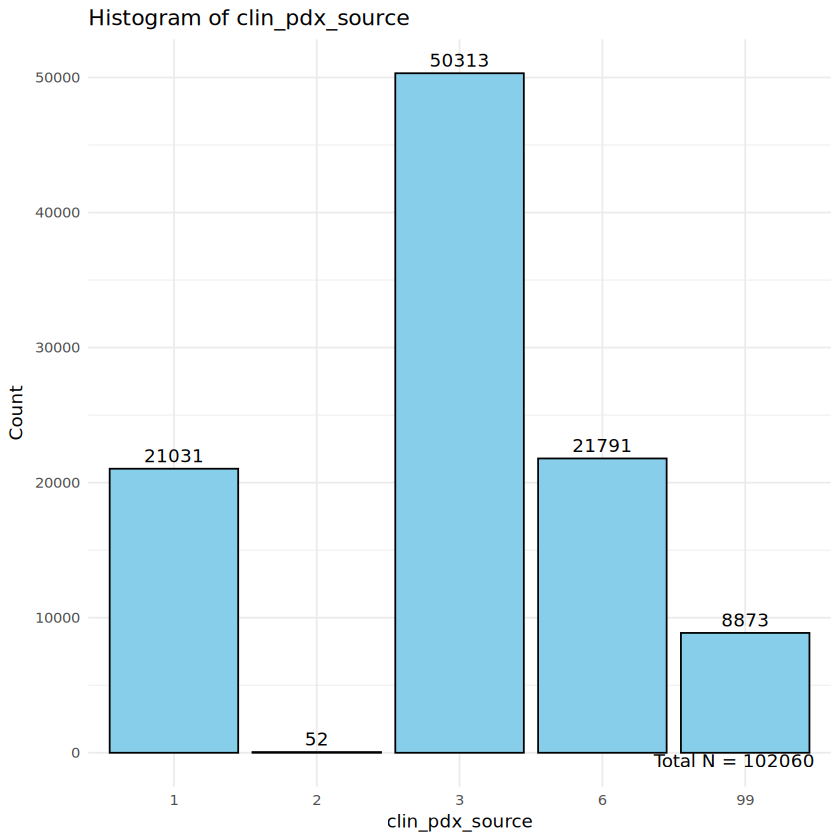

In [25]:
# Assuming dt is your data.table
# Calculate counts per category and total count
count_data <- dt[, .N, by = clin_pdx_source]
setorder(count_data, clin_pdx_source)
count_data[, clin_pdx_source := factor(clin_pdx_source, levels = c(1, 2, 3, 6, 99))]

# Calculate total count
total_count <- sum(count_data$N)

# Plot histogram with counts on top of each bar and total count below
ggplot(count_data, aes(x = clin_pdx_source, y = N)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black") +
  labs(title = "Histogram of clin_pdx_source", x = "clin_pdx_source", y = "Count") +
  theme_minimal() +
  scale_x_discrete(drop = FALSE) + # Ensures all categories are shown
  geom_text(aes(label = N), vjust = -0.5) + # Display count above each bar
  annotate("text", x = Inf, y = -Inf, label = paste("Total N =", total_count), hjust = 1.1, vjust = -1.5) # Display total count below


In [ ]:
str(dt)


Classes ‘data.table’ and 'data.frame':	102060 obs. of  39 variables:
 $ id_year          : num  2022 2022 2022 2022 2022 ...
 $ id_series        : chr  "7009017009013012209007" "9103789103012902203019" "5101955101060303201015" "6101306101130203211016" ...
 $ id_pin           : chr  "12E7C6E880E651AB2AE91954A6753393" "481266642E0D8BB53DF37A196E87EDC1" "FE6730FFDE7474EAD38F330A6C4B403F" "565711CAE81EC5F7DB4B3B031478F47E" ...
 $ id_hci           : chr  "440901" "Z03199" "Z04606" "591201" ...
 $ id_hcp           :List of 102060
  ..$ : chr "34333"
  ..$ : chr "59359"
  ..$ : chr "59139"
  ..$ : chr "38465"
  ..$ : chr "20840"
  ..$ : chr "63160"
  ..$ : chr "4958"
  ..$ : chr "69525"
  ..$ : chr "15064"
  ..$ : chr "35811"
  ..$ : chr "46845"
  ..$ : chr  "51029" "68803"
  ..$ : chr "37927"
  ..$ : chr "1840"
  ..$ : chr "52106"
  ..$ : chr "30588"
  ..$ : chr "55737"
  ..$ : chr "36789"
  ..$ : chr  "23765" "34443"
  ..$ : chr "47519"
  ..$ : chr "35355"
  ..$ : chr "12416"
  ..$ : chr "1

In [27]:
print(unique(dt$clin_rvs))


[[1]]
character(0)

[[2]]
[1] "99460"

[[3]]
[1] "31500"

[[4]]
[1] "99460" "NA"   

[[5]]
[1] "CR0388"

[[6]]
[1] "99460"  "NAP369"

[[7]]
[1] "ZO38"

[[8]]
[1] "AO10"

[[9]]
[1] "ICD"

[[10]]
[1] "UO71"

[[11]]
[1] "KO11"

[[12]]
[1] "NI85"

[[13]]
[1] "27410"

[[14]]
[1] "NONEP599"

[[15]]
[1] "99460"  "CR4660"

[[16]]
[1] "NONEO809"

[[17]]
[1] "99460" "PO02" 

[[18]]
[1] "99460"  "NAP081"

[[19]]
[1] "FO001"

[[20]]
[1] "99460"  "NAP209"

[[21]]
[1] "08000"

[[22]]
[1] "NAO756"

[[23]]
[1] "32408"

[[24]]
[1] "NONEO820"

[[25]]
[1] "NECS628"

[[26]]
[1] "NONEO234"

[[27]]
[1] "RFRHD11" "NA"     

[[28]]
[1] "99460"  "NAP017"

[[29]]
[1] "99460"  "NAP051"

[[30]]
[1] "31500" "99460"

[[31]]
[1] "CR4713"

[[32]]
[1] "99460"  "NAP240"

[[33]]
[1] "99460"  "NAZ380"

[[34]]
[1] "99640" "99460" "NA"   

[[35]]
[1] "99460"  "NAP015"

[[36]]
[1] "99460"  "CR4687"

[[37]]
[1] "26488"

[[38]]
[1] "01961"

[[39]]
[1] "99460"  "NAQ000"

[[40]]
[1] "NONEO244"

[[41]]
[1] "CR4651"

[[42]]
[1] "

In [ ]:
print(unique(dt$clin_proc))


# Post Cleaning Steps


Part 1: Stata Modifications


In [15]:
result <- readRDS(here(
  checkpoint_2_path,
  paste0(checkpoint_2_prefix, year_to_load, suffix, "final", ".rds")
))

# Convert both id_hci and PMCC_NO to characters
# to ensure consistency for joining
result[, id_hci := as.character(id_hci)]
hci[, PMCC_NO := as.character(PMCC_NO)]

# Remove leading zeros from numeric PMCC_NO values,
# while preserving non-numeric values
hci[, PMCC_NO_stripped := fifelse(
  grepl("^[0-9]+$", PMCC_NO),
  sub("^0+", "", PMCC_NO), # Remove leading zeros from numeric strings
  PMCC_NO # Keep non-numeric values unchanged
)]

# Keep only necessary columns from hci for the join
hci_subset <- hci[, .(
  PMCC_NO_stripped,
  SOC_SECTOR, INST_NAME, CAT_24,
  REGION_NAME, PROVINCE_NAME
)]

# Perform a left join, keeping all rows in
# result and only matching rows from hci
result <- merge(
  result,
  hci_subset,
  by.x = "id_hci",
  by.y = "PMCC_NO_stripped",
  all.x = TRUE, # Keep all rows from result
  all.y = FALSE # Only include matching rows from hci
)

# ----- Filter rows by allowed CAT_24 categories -----
allowed_categories <- c(
  "INFIRMARY/DISPENSARY",
  "LEVEL 1 HOSPITAL", "LEVEL 2 HOSPITAL", "LEVEL 3 HOSPITAL"
)

# Count rows where CAT_24 is not in allowed categories
count_excluded <- result[
  !(CAT_24 %in% allowed_categories), .N
]
cat(
  "Number of rows where CAT_24 is not in the allowed categories:",
  count_excluded, "\n"
)


# Drop rows where CAT_24 is not in the allowed categories
result <- result[CAT_24 %in% allowed_categories]
# ----- Filter rows where clin_outpatient is TRUE -----
# Count rows where clin_outpatient is TRUE
count_clin_outpatient_true <- result[
  clin_outpatient == TRUE, .N
]
cat(
  "Number of rows where clin_outpatient is TRUE:",
  count_clin_outpatient_true, "\n"
)

# Drop rows where clin_outpatient is TRUE
result <- result[clin_outpatient != TRUE]
# ----- Filter rows where claim_status is not "G" -----
# Count rows where claim_status is not "G"
count_claim_status_not_g <- result[
  claim_status != "G", .N
]
cat(
  "Number of rows where claim_status is not 'G':",
  count_claim_status_not_g, "\n"
)

# Drop rows where claim_status is not "G"
result <- result[claim_status == "G"]
# Convert 'c1' from a list of character vectors
# into a single concatenated string
result[, c1_spc := sapply(c1, function(x) {
  if (is.null(x) || all(is.na(x))) {
    return(NA_character_) # Return NA if the list is empty or all values are NA
  } else {
    # Sort, remove duplicates, and concatenate
    return(paste(sort(unique(x)), collapse = ","))
  }
})]

# ----- Handle duplicate rows based on specific columns -----
duplicate_columns <- c(
  "id_pin", "pat_type", "pat_age",
  "pat_sex", "date_adm", "date_dis", "c1_spc", "claim_payout"
)

# Count duplicate rows based on the specified columns
count_duplicates <- result[
  duplicated(result[, ..duplicate_columns]), .N
]
cat(
  "Number of duplicated rows based on specified columns:",
  count_duplicates, "\n"
)

# Drop duplicate rows, keeping only the first occurrence
result <- result[!duplicated(result[, ..duplicate_columns])]
# ----- Remove unnecessary columns and reorder remaining columns -----
# Remove unnecessary columns
result[, c("c1", "c1_spc", "c2", "clin_rvs") := NULL]

# Perform garbage collection to free up memory
gc()

# Set the column order to a specified structure
setcolorder(result, c(
  "id_year", "id_series", "id_pin", "id_hci", "id_hcp", "date_adm",
  "time_adm", "date_dis", "time_dis", "date_rec", "date_ref",
  "date_check", "date_ext", "pat_type", "pat_rel", "pat_bdate", "pat_age",
  "pat_ageday", "pat_sex", "pat_bwt", "pat_memcat_parent", "pat_memcat_child",
  "is_covid", "claim_status", "claim_payout", "claim_charge", "clin_discharge",
  "clin_outpatient", "clin_emergency", "clin_acc", "clin_c1", "clin_c2",
  "clin_sdx", "clin_proc", "clin_pdx", "clin_pdx_source", "SOC_SECTOR",
  "CAT_24", "INST_NAME", "REGION_NAME", "PROVINCE_NAME"
))

saveRDS(
  result,
  here(
    checkpoint_2_path,
    paste0(checkpoint_2_prefix, year_to_load, suffix, "stata", ".rds")
  ),
  compress = TRUE
)


Number of rows where CAT_24 is not in the allowed categories: 25655 
Number of rows where clin_outpatient is TRUE: 38004 
Number of rows where claim_status is not 'G': 1799 
Number of duplicated rows based on specified columns: 0 


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3316971,177.2,6681051,356.9,6681051,356.9
Vcells,12618358,96.3,41194653,314.3,49394815,376.9


# Part 2: Final Checks


Part 2A: Final Checks - Checking for Exponential Form Numbers


In [16]:
print(result[grepl("e", id_series)])
print(result[grepl("e", id_pin)])
print(result[grepl("e", id_hci)])
# Search for rows where any element in clin_sdx is "A"
result[, if (any(sapply(
  clin_sdx,
  function(row) "A" %in% row
))) {
  print(.SD)
}, by = seq_len(nrow(result))]


Key: <id_hci>
Empty data.table (0 rows and 41 cols): id_year,id_series,id_pin,id_hci,id_hcp,date_adm...
Key: <id_hci>
Empty data.table (0 rows and 41 cols): id_year,id_series,id_pin,id_hci,id_hcp,date_adm...
Key: <id_hci>
Empty data.table (0 rows and 41 cols): id_year,id_series,id_pin,id_hci,id_hcp,date_adm...


seq_len
<int>


Part 2B: Final Checks - Checking for Dates Before 1900


In [17]:
result <- readRDS(here(
  checkpoint_2_path,
  paste0(checkpoint_2_prefix, year_to_load, suffix, "final", ".rds")
))
date_cols <- c(
  "date_adm", "date_dis", "date_rec", "date_ref",
  "date_check", "pat_bdate", "date_ext"
)

# Find rows where any date column has a date before 1900-01-01
rows_with_old_dates <- result[Reduce(`|`, lapply(
  .SD,
  function(x) x < as.Date("1900-01-01")
)), .SDcols = date_cols]

# Print the resulting rows
print(rows_with_old_dates)


Null data.table (0 rows and 0 cols)


Part 2C: Final Checks - Dropping Duplicate Columns


In [18]:
result <- readRDS(here(
  checkpoint_2_path,
  paste0(checkpoint_2_prefix, year_to_load, suffix, "final", ".rds")
))
result[, c("c1", "c2", "clin_rvs") := NULL]


Part 2D: Final Checks - Checking Age Changes


In [19]:
before <- readRDS(here(
  checkpoint_2_path,
  paste0(checkpoint_2_prefix, year_to_load, suffix, ".rds")
))
after <- readRDS(here(
  checkpoint_2_path,
  paste0(checkpoint_2_prefix, year_to_load, suffix, "final", ".rds")
))

# Ensure both data.tables have the same key columns for comparison
setkey(before, id_series)
setkey(after, id_series)

# Identify rows where pat_age is different
# between the two tables, handling NA values
pat_age_diff_na <- before[after,
  on = .(id_series), nomatch = 0,
  # Explicitly name pat_age_before as coming from "before"
  .(id_series, pat_bdate,
    pat_age_before = x.pat_age,
    pat_age_after = i.pat_age
  ),
  by = .EACHI
]

# Filter to show rows where one value is NA and
# the other is not or the values are simply different
pat_age_diff_na <- pat_age_diff_na[
  (is.na(pat_age_before) & !is.na(pat_age_after)) |
    (!is.na(pat_age_before) & is.na(pat_age_after)) |
    (pat_age_before != pat_age_after)
]

# Print the differences
cat("Rows where pat_age is NA in one table but
not in the other, or where the values differ:\n")
print(pat_age_diff_na)


Rows where pat_age is NA in one table but
not in the other, or where the values differ:
Key: <id_series>
Empty data.table (0 rows and 5 cols): id_series,id_series,pat_bdate,pat_age_before,pat_age_after


# BQ Upload


In [20]:
if (nrow(result) == total_rows) bq_table <- paste0("claims_", year_to_load)

# Check if the table should be dropped and replaced
tryCatch(
  {
    bq_table_delete(bq_table(gcp_proj, bq_dataset, bq_table))
    message("Table dropped successfully.\n")
  },
  error = function(e) {
    # If the table does not exist, just continue
    if (grepl("Not found", e, ignore.case = TRUE)) {
      message("Table does not exist, nothing to drop.\n")
    } else {
      # If it's a different error, re-throw the error
      stop(e)
    }
  }
)

# Attempt to create the table
tryCatch(
  {
    bq_table_create(
      bq_table(gcp_proj, bq_dataset, bq_table),
      fields = fromJSON(here(
        "data-cleaning/r_scripts_v2",
        "bq_schema_cleaning.json"
      ), simplifyDataFrame = FALSE)
    )
    message("Table created successfully.\n")
  },
  error = function(e) {
    # Check if the error message indicates that the table already exists
    if (grepl("already exists", e, ignore.case = TRUE)) {
      message("Table already exists. Skipping creation and upload.")
    } else {
      # If it's a different error, re-throw the error
      stop(e)
    }
  }
)

# Upload to BQ only if table is empty
if (to_write) {
  chunk_size <- 1000000 # Adjust the chunk size based on memory availability
  num_chunks <- ceiling(nrow(result) / chunk_size)

  for (i in seq_len(num_chunks)) {
    chunk <- result[
      ((i - 1) * chunk_size + 1):min(i * chunk_size, nrow(result)),
    ]

    bq_table_upload(
      bq_table(gcp_proj, bq_dataset, bq_table),
      values = chunk,
      write_disposition = if (i == 1) "WRITE_EMPTY" else "WRITE_APPEND"
    )
  }
}


Table dropped successfully.


Table created successfully.




# Debug Steps


In [21]:
concatenate_r_files <- function(input_path, output_file) {
  # List all .R files in the directory
  r_files <- list.files(
    path = input_path,
    pattern = "\\.R$", full.names = TRUE
  )

  # Delete the existing output file if it exists
  if (file.exists(output_file)) {
    file.remove(output_file)
  }

  # Read and concatenate contents
  file_contents <- lapply(r_files, readLines)
  concatenated_content <- unlist(file_contents)

  # Write concatenated content to the output file
  cat(concatenated_content, file = output_file, sep = "\n")
}

# Consolidate all r_scripts scripts into debug.R; useful for debugging
concatenate_r_files(
  here::here("data-cleaning/r_scripts_v2"),
  here::here("data-cleaning/debug/r_scripts_v2.R")
)

system(
  paste(
    "cd ~/drg-pipeline &&",
    "jupyter nbconvert",
    "--no-prompt",
    "--to script data-cleaning/drg-cleaning-v2.ipynb",
    "--output debug/drg-cleaning-v2"
  )
)


# Clean-up Steps


In [22]:
# Assign values using regular assignment (no need for <<- if declared globally)
if (TRUE) {
  to_debug <- FALSE
  to_flush_master <- FALSE
  to_flush_partial <- FALSE
}

# Define the paths and their corresponding conditions
paths <- list(
  to_flush_master = c(
    "data-cleaning/cache",
    "data-cleaning/data/profvis",
    "data-cleaning/data/aux-files",
    "data-cleaning/data/checkpoints",
    "data-cleaning/debug"
  ),
  to_flush_partial = c(
    "data-cleaning/data/claims/raw/parts",
    "data-cleaning/data/claims/raw/samples"
  )
)

# Iterate over the paths and delete directories if the corresponding condition is true
for (condition in names(paths)) {
  if (get(condition, envir = .GlobalEnv)) { # Ensure the variables are accessed in the global environment
    system(paste(
      "rm -r",
      paste(here::here(unlist(paths[[condition]])), collapse = " ")
    ))
  }
}

# Clean up the environment and run garbage collection if debugging is enabled
if (to_debug) {
  rm(list = ls(), envir = .GlobalEnv) # Ensure global environment is cleared
  gc()
}
